# Task 2: End-to-End ML Pipeline for Customer Churn Prediction
**Objective:** Build a reusable scikit-learn pipeline to predict customer churn  
**Dataset:** Telco Customer Churn  
**Models:** Logistic Regression + Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
# Load Telco Churn dataset directly from URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
Paymen

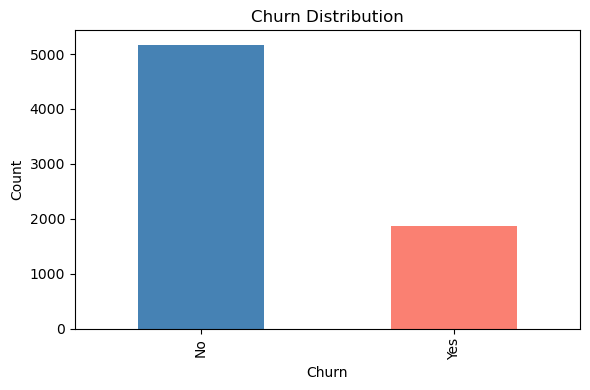

In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

# Plot churn distribution
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [4]:
# Fix TotalCharges - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Drop customer ID (not useful)
df.drop('customerID', axis=1, inplace=True)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Processed shape:", df.shape)
print("Churn value counts:\n", df['Churn'].value_counts())

Processed shape: (7032, 20)
Churn value counts:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [5]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train size: 5625, Test size: 1407


In [6]:
# Preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Pipeline with Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Pipeline with Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Pipelines created successfully!")

Pipelines created successfully!


In [7]:
# Hyperparameter grids
lr_params = {'classifier__C': [0.01, 0.1, 1, 10]}
rf_params = {'classifier__n_estimators': [50, 100], 'classifier__max_depth': [5, 10, None]}

# Grid search for Logistic Regression
lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)
print("Best LR params:", lr_grid.best_params_)

# Grid search for Random Forest
rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)
print("Best RF params:", rf_grid.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best LR params: {'classifier__C': 10}
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best RF params: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}


In [8]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model("Logistic Regression", lr_grid, X_test, y_test)
rf_pred, rf_prob = evaluate_model("Random Forest", rf_grid, X_test, y_test)


  Logistic Regression
Accuracy : 0.8003
F1 Score : 0.6025
ROC-AUC  : 0.8351

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.73      1407
weighted avg       0.79      0.80      0.80      1407


  Random Forest
Accuracy : 0.7932
F1 Score : 0.5714
ROC-AUC  : 0.8303

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



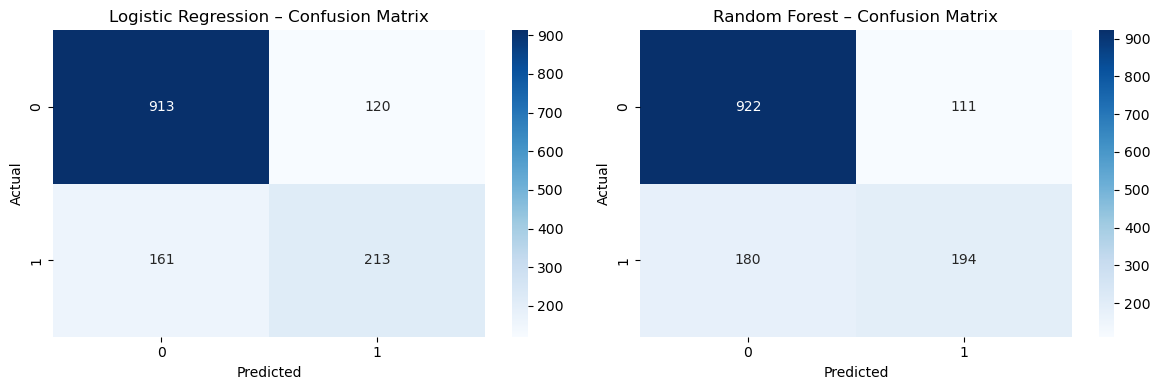

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, pred in zip(axes, ['Logistic Regression','Random Forest'], [lr_pred, rf_pred]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name} – Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

In [10]:
# Save the best model (Random Forest in this case)
best_model = rf_grid if rf_grid.best_score_ > lr_grid.best_score_ else lr_grid
joblib.dump(best_model, 'churn_pipeline.pkl')
print("Pipeline saved as churn_pipeline.pkl")

# Test loading it back
loaded_pipeline = joblib.load('churn_pipeline.pkl')
sample = X_test.iloc[:3]
print("Test prediction:", loaded_pipeline.predict(sample))

Pipeline saved as churn_pipeline.pkl
Test prediction: [0 1 0]


## Summary & Insights
- Random Forest outperformed Logistic Regression on F1 and ROC-AUC
- GridSearchCV improved model performance by tuning hyperparameters
- The pipeline handles all preprocessing automatically — production-ready!
- Key churn drivers: Contract type, tenure, monthly charges